In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [4]:
data = pd.read_csv('synthetic_regression_dataset.csv')

In [5]:
x = data[['Feature']]
y = data[['Target']]

In [6]:
scaler = MinMaxScaler()
x_normalized = scaler.fit_transform(x)

In [7]:
x_train, x_test, y_train, y_test = train_test_split( x_normalized, y, test_size = 0.2, random_state = 42)

In [8]:
print("x_train",x_train)
print("y_train",y_train.values)
print("x_test",x_test)
print("y_test",y_test.values)

x_train [[0.38593066]
 [0.45867779]
 [0.47253883]
 [0.56100008]
 [0.44425319]
 [0.46109727]
 [0.39314371]
 [0.4855076 ]
 [0.41959557]
 [0.5058993 ]
 [0.53737785]
 [0.3615556 ]
 [0.0876124 ]
 [0.44603413]
 [0.5200136 ]
 [0.2673833 ]
 [0.50298778]
 [0.38823547]
 [0.37557994]
 [0.5580505 ]
 [0.43073144]
 [0.38393804]
 [0.46332672]
 [0.32896871]
 [0.34649203]
 [0.38816769]
 [0.60542851]
 [0.61890913]
 [0.32740566]
 [0.78318675]
 [0.40564641]
 [0.37811474]
 [0.47344168]
 [0.344569  ]
 [0.53817662]
 [0.34099906]
 [0.32307144]
 [0.34053715]
 [0.62032674]
 [0.36144715]
 [0.4831861 ]
 [0.44433998]
 [0.60244338]
 [0.41445787]
 [0.47300473]
 [0.51952795]
 [0.50258696]
 [0.43887091]
 [0.7604244 ]
 [0.50393713]
 [0.48105951]
 [0.50722913]
 [0.41150357]
 [0.55361142]
 [0.26866694]
 [0.37573295]
 [0.41892599]
 [0.60925413]
 [0.4977506 ]
 [0.59399809]
 [0.24848402]
 [0.37764029]
 [0.52163068]
 [0.35714664]
 [0.49221325]
 [0.46358423]
 [0.30605905]
 [0.49651252]
 [0.38321747]
 [0.23045127]
 [0.32059368

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Input

2025-07-10 11:15:11.939686: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-10 11:15:11.940254: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 11:15:11.942299: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 11:15:11.947667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752126311.956646  191161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752126311.95

In [10]:
model = Sequential()

In [11]:
model.add(Input(shape=(x_train.shape[1],)))  # Shape of input features
model.add(Dense(64, activation='relu'))  # First hidden layer
model.add(Dense(32, activation='relu'))  # Second hidden layer
model.add(Dense(1))  # Output layer

2025-07-10 11:15:12.888668: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [27]:
loss_fn = MeanSquaredError()
optimizer = Adam(learning_rate = 0.001)
model.compile(optimizer = optimizer, loss = loss_fn)
history = model.fit(x_train, y_train, epochs = 500, batch_size = 32, validation_split = 0.2)
test_loss = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")

predictions = model.predict(x_test)
print(f"Predictions (first 5): {predictions[:5]}")

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 102.8501 - val_loss: 102.7433
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 104.8690 - val_loss: 98.1987
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 98.3658 - val_loss: 99.3675
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 90.7824 - val_loss: 99.6719
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 97.4361 - val_loss: 99.9113
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 92.5137 - val_loss: 100.9152
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 88.7763 - val_loss: 99.3120
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 89.4479 - val_loss: 97.9464
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 95.7003 - val_loss: 97.6830
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 96.0651 - val_loss: 97.9378
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 100.2261 - val_loss: 97.0338
Epoch 12/500
20/20 ━━━━━━━━━━━━━━━━━

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Evaluate the model on the test data
test_loss = model.evaluate(x_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Make predictions on the test data
y_pred = model.predict(x_test)

# Calculate MAE, MSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 108.8877 
Test Loss (MSE): 109.1141128540039
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Mean Absolute Error (MAE): 8.208064071686245
Mean Squared Error (MSE): 109.11411333569922
R² Score: 0.7156480904944917


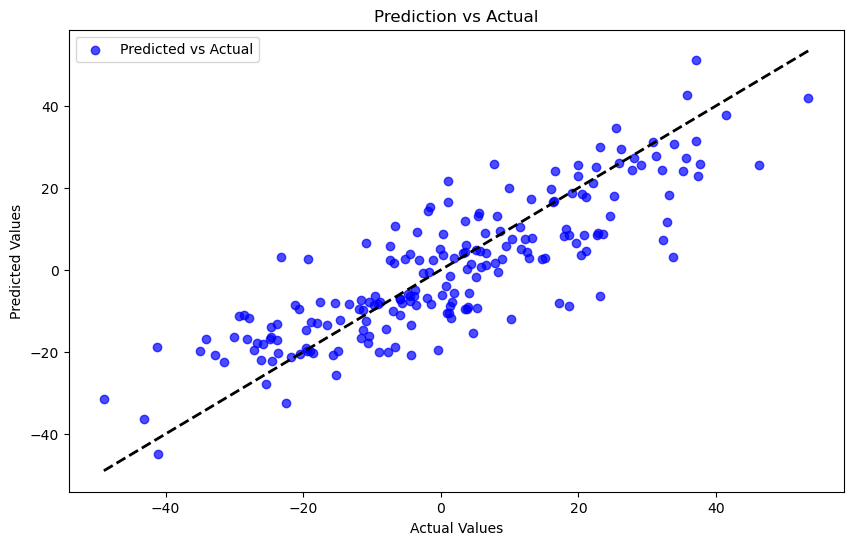

In [29]:
# Plotting Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line of equality
plt.title('Prediction vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


In [30]:
# New architecture with more layers and neurons
model = Sequential()
model.add(Dense(128, input_dim=x_train.shape[1], activation='relu'))  # Increased neurons
model.add(Dense(64, activation='relu'))  # Second hidden layer with more neurons
model.add(Dense(32, activation='relu'))  # Third hidden layer
model.add(Dense(1))  # Output layer (regression, no activation)

# Compile and train the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_split=0.2)


Epoch 1/500


/home/ai-a2/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 332.8697 - val_loss: 393.7526
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 324.5581 - val_loss: 391.3847
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 335.1142 - val_loss: 386.9832
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 362.0828 - val_loss: 378.1452
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 301.1162 - val_loss: 360.4510
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 309.3043 - val_loss: 331.9905
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 315.2297 - val_loss: 289.6122
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 231.3705 - val_loss: 230.3361
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 220.9898 - val_loss: 167.9973
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 149.4910 - val_loss: 123.2826
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 119.8751 - val_loss: 110.0385
Epoch 12/500
20/20 ━━━━━━━━━━━━

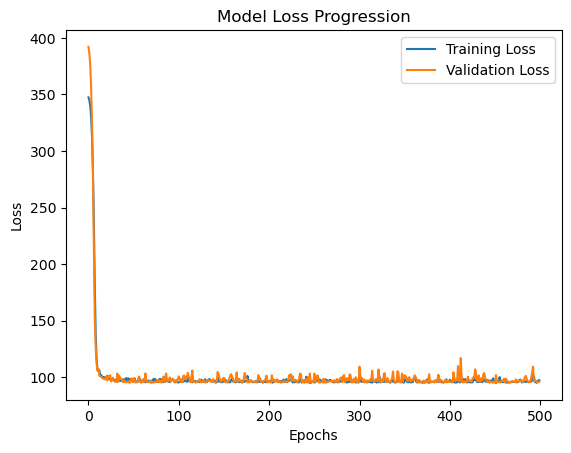

In [16]:
# Plotting the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [17]:
# Evaluate on the test set
test_loss = model.evaluate(x_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Make predictions on the test set
y_pred = model.predict(x_test)

# Calculate MAE, MSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 106.7639 
Test Loss (MSE): 108.10493469238281
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Absolute Error (MAE): 8.157944360570893
Mean Squared Error (MSE): 108.10493630351884
R² Score: 0.7182780107436417


In [18]:
from tensorflow.keras.layers import Dropout

# New model with Dropout for regularization
model = Sequential()
model.add(Dense(128, input_dim=x_train.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout with 20% rate
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))  # Another dropout layer
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Output layer

# Compile and train the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_split=0.2)


Epoch 1/500


/home/ai-a2/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 368.8148 - val_loss: 390.3349
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 345.7813 - val_loss: 383.3522
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332.4877 - val_loss: 370.2942
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 328.6510 - val_loss: 348.2653
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 327.6758 - val_loss: 318.3067
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 274.2505 - val_loss: 276.0101
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 250.7234 - val_loss: 243.3313
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 223.1531 - val_loss: 211.3658
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 194.6596 - val_loss: 189.7751
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 192.8547 - val_loss: 168.8426
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 166.1996 - val_loss: 157.9714
Epoch 12/500
20/20 ━━━━━━━━━━━━

In [19]:
from tensorflow.keras.callbacks import LearningRateScheduler

# Learning rate schedule function
def scheduler(epoch, lr):
    if epoch < 50:
        return lr
    elif epoch < 150:
        return lr * 0.1
    elif epoch < 300:
        return lr * 0.01
    else:
        return lr * 0.001

lr_scheduler = LearningRateScheduler(scheduler)

# Train the model with the learning rate scheduler
history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_split=0.2, callbacks=[lr_scheduler])


Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 95.1241 - val_loss: 99.1671 - learning_rate: 0.0010
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.2803 - val_loss: 96.9321 - learning_rate: 0.0010
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 99.4179 - val_loss: 97.0377 - learning_rate: 0.0010
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 104.4268 - val_loss: 98.4406 - learning_rate: 0.0010
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 104.5806 - val_loss: 100.1862 - learning_rate: 0.0010
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 93.8776 - val_loss: 98.2931 - learning_rate: 0.0010
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105.5030 - val_loss: 98.7467 - learning_rate: 0.0010
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 109.8949 - val_loss: 96.3120 - learning_rate: 0.0010
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 101.8541 - val_loss: 99.5703 - learning_rate: 0

In [20]:
# Evaluate on the test set again
test_loss = model.evaluate(x_test, y_test)
print(f"Test Loss (MSE): {test_loss}")

# Make predictions on the test set
y_pred = model.predict(x_test)

# Calculate MAE, MSE, and R² score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.5727 
Test Loss (MSE): 107.95389556884766
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Absolute Error (MAE): 8.1038604398081
Mean Squared Error (MSE): 107.95389052397057
R² Score: 0.7186716367790306


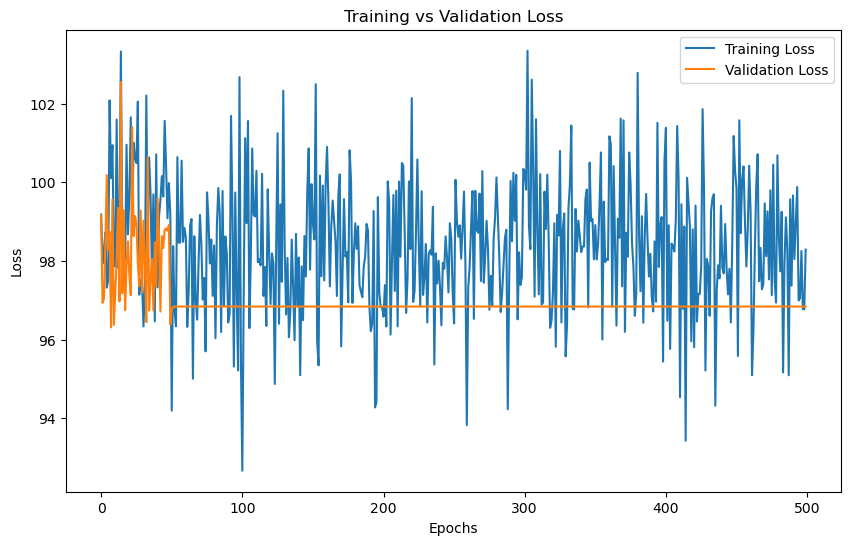

In [21]:
import matplotlib.pyplot as plt

# Plot the training and validation loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


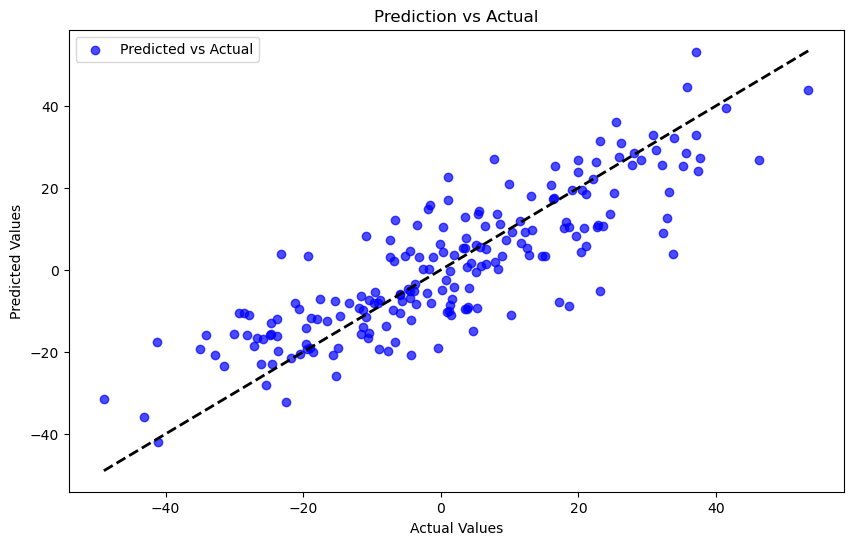

In [22]:
# Make predictions on the test set
y_pred = model.predict(x_test)

# Plotting Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Line of equality
plt.title('Prediction vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()
